<img src="https://raw.githubusercontent.com/carubbi/MQ/main/notebooks/assets/imgs/unifor-logo.png" width="400">
<br>
<b>
<font size="6" face="arial" color="blue">
    Graduação em Ciência da Computação
</font>
</b>
<br>
<b>
<font size="4" face="arial">
    Disciplina: Métodos Quantitativos em Computação
</font>
</b>

**Orientador: Prof. Me. Ricardo Carubbi** <br>
*Docente da Graduação e Pós-Graduação em Ciência de Dados e Inteligência Artificial*<br>
*Laboratório de Ciência de Dados e Inteligência Artificial*<br>
*Universidade de Fortaleza*<br>

# **Aula 9 — Associação entre Variáveis Qualitativas**

## 1. Objetivos de aprendizagem

Ao final da aula, o aluno será capaz de:

- construir e interpretar tabelas de contingência e suas frequências marginais.
- calcular percentuais condicionais, identificando o denominador adequado à pergunta.
- comparar perfis percentuais e resumos quantitativos por grupo.
- distinguir associação observada de uma conclusão causal.

## 2. Agenda

1. Escolha das variáveis e do procedimento — 15 min
2. Tabelas de contingência — 25 min
3. Percentuais condicionais e associação — 30 min
4. Comparação entre grupos — 30 min

O carregamento, a inspeção da base e o código dos gráficos são apresentados prontos. O Q–Q entre grupos é uma demonstração pronta para interpretação.

## 3. Escolha das variáveis e do procedimento

A **análise bivariada** examina duas variáveis em conjunto. A pergunta e os tipos das variáveis orientam a escolha do procedimento (MORETTIN; BUSSAB, 2010, pp. 85–86).

| Tipos | Exemplo | Procedimento |
| --- | --- | --- |
| Qualitativa e qualitativa | Ilha e espécie | Tabela de contingência e percentuais |
| Qualitativa e quantitativa | Espécie e massa corporal | Medidas e gráficos por grupo |
| Quantitativa e quantitativa | Massa e comprimento da nadadeira | Dispersão e correlação, na Aula 10 |

Nesta aula, responderemos:

1. Como a distribuição das espécies muda entre as ilhas?
2. Como a massa corporal varia entre as espécies?

Usaremos a base processada e exportada na Aula 5.

In [1]:
# Importar as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Manter a ordem e as cores das categorias
especies = ['Adelie', 'Chinstrap', 'Gentoo']
ilhas = ['Biscoe', 'Dream', 'Torgersen']
cores = ['darkorange', 'purple', '#008B8B']
cores_ilhas = ['#377eb8', '#e41a1c', '#4daf4a']

In [2]:
# Carregar a base processada do GitHub
url = 'https://raw.githubusercontent.com/carubbi/MQ/main/data/processed/penguins.csv'
df = pd.read_csv(url)
df.head()

,ID,SPECIES,ISLAND,SEX,DATE_EGG,YEAR,CULMEN_LENGTH,CULMEN_DEPTH,FLIPPER_LENGTH,BODY_MASS
0,PAL0708_N1A1,Adelie,Torgersen,male,2007-11-11,2007,39.1,18.7,181.0,3750.0
1,PAL0708_N1A2,Adelie,Torgersen,female,2007-11-11,2007,39.5,17.4,186.0,3800.0
2,PAL0708_N2A1,Adelie,Torgersen,female,2007-11-16,2007,40.3,18.0,195.0,3250.0
3,PAL0708_N2A2,Adelie,Torgersen,NaN,2007-11-16,2007,NaN,NaN,NaN,NaN
4,PAL0708_N3A1,Adelie,Torgersen,female,2007-11-16,2007,36.7,19.3,193.0,3450.0


In [3]:
# Conferir os tipos e os valores preenchidos
df.info()

# Contar valores válidos nas variáveis da aula
df[['SPECIES', 'ISLAND', 'BODY_MASS']].count()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              344 non-null    str    
 1   SPECIES         344 non-null    str    
 2   ISLAND          344 non-null    str    
 3   SEX             333 non-null    str    
 4   DATE_EGG        344 non-null    str    
 5   YEAR            344 non-null    int64  
 6   CULMEN_LENGTH   342 non-null    float64
 7   CULMEN_DEPTH    342 non-null    float64
 8   FLIPPER_LENGTH  342 non-null    float64
 9   BODY_MASS       342 non-null    float64
dtypes: float64(4), int64(1), str(5)
memory usage: 27.0 KB


SPECIES      344
ISLAND       344
BODY_MASS    342
dtype: int64

A base contém 344 registros. Espécie e ilha estão preenchidas em todos eles. A massa corporal está preenchida em 342 registros. Cada análise deve usar o total válido das variáveis envolvidas.

## 4. Tabelas de contingência

Uma **tabela de contingência**, ou tabela de dupla entrada, cruza as categorias de duas variáveis qualitativas (PINHEIRO et al., 2009, pp. 60–65).

### 4.1 Frequências conjuntas e marginais

A **frequência conjunta** conta as observações que pertencem simultaneamente à categoria da linha e à categoria da coluna. As **frequências marginais** são os totais por linha ou por coluna (MORETTIN; BUSSAB, 2010, pp. 87–89).

Notação:

- $i$: índice da linha, correspondente à ilha.
- $j$: índice da coluna, correspondente à espécie.
- $n_{ij}$: contagem na célula da linha $i$ e coluna $j$.
- $n_{i\cdot}$: total da linha $i$.
- $n_{\cdot j}$: total da coluna $j$.
- $n$: total de observações válidas da tabela.

`pd.crosstab()` conta os cruzamentos. `margins=True` acrescenta os totais.

In [4]:
# Cruzar ilha e espécie com totais
tab = pd.crosstab(df['ISLAND'], df['SPECIES'], margins=True, margins_name='Total')
tab

SPECIES,Adelie,Chinstrap,Gentoo,Total
ISLAND,,,,
Biscoe,44,0,124,168
Dream,56,68,0,124
Torgersen,52,0,0,52
Total,152,68,124,344


In [5]:
# Conferir uma célula e suas marginais
print('Gentoo em Biscoe:', tab.loc['Biscoe', 'Gentoo'])
print('Total de Biscoe:', tab.loc['Biscoe', 'Total'])
print('Total de Gentoo:', tab.loc['Total', 'Gentoo'])
print('Total válido:', tab.loc['Total', 'Total'])

Gentoo em Biscoe: 124
Total de Biscoe: 168
Total de Gentoo: 124
Total válido: 344


Há 124 registros de Gentoo em Biscoe. O total de Biscoe é 168 e o total de Gentoo é 124. A soma das contagens internas é 344.

Uma célula zero indica que aquela combinação não aparece na base. Não significa que seja impossível na população. Um valor ausente não deve ser contado como zero.

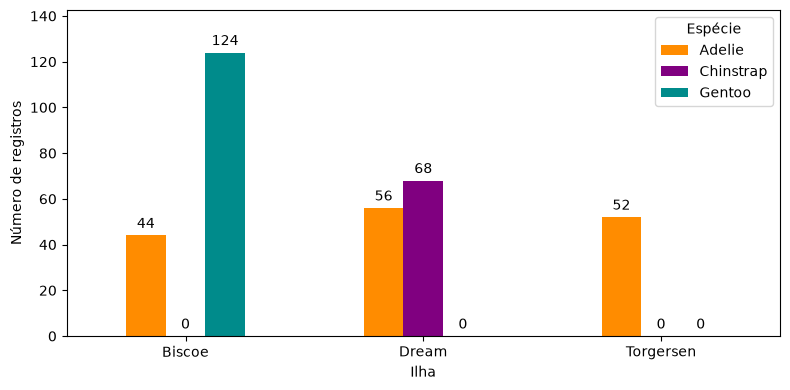

In [6]:
# Representar as contagens conjuntas
cont = tab.loc[ilhas, especies]
ax = cont.plot.bar(color=cores, figsize=(8, 4), rot=0)
ax.set(xlabel='Ilha', ylabel='Número de registros')
ax.legend(title='Espécie')

# Mostrar a contagem acima de cada barra
for barras in ax.containers:
    ax.bar_label(barras, fmt='%.0f', padding=3)
ax.margins(y=0.15)

plt.tight_layout()
plt.show()

**Figura 1 — Contagens por ilha e espécie.** Gentoo aparece apenas em Biscoe e Chinstrap apenas em Dream nesta base. Adelie aparece nas três ilhas. As alturas mostram contagens, ainda sem considerar os diferentes tamanhos dos grupos. Fonte: CARUBBI, 2026, com dados de HORST; HILL; GORMAN, 2020.

### 4.2 Percentuais do total

O **percentual conjunto** usa o total válido da tabela como denominador:

$$100\frac{n_{ij}}{n}.
\tag{9.1}
$$

Ele responde à pergunta: “Qual percentual de todos os registros pertence a esta ilha **e** a esta espécie?” (MORETTIN; BUSSAB, 2010, pp. 87–89).

In [7]:
# Calcular percentuais em relação ao total válido
pct = 100 * cont / tab.loc['Total', 'Total']
pct.round(2)

SPECIES,Adelie,Chinstrap,Gentoo
ISLAND,,,
Biscoe,12.79,0.00,36.05
Dream,16.28,19.77,0.00
Torgersen,15.12,0.00,0.00


In [8]:
# Conferir o percentual conjunto e a soma
print('Gentoo em Biscoe (%):', round(100 * 124 / 344, 2))
print('Soma dos percentuais (%):', pct.sum().sum())

Gentoo em Biscoe (%): 36.05
Soma dos percentuais (%): 100.0


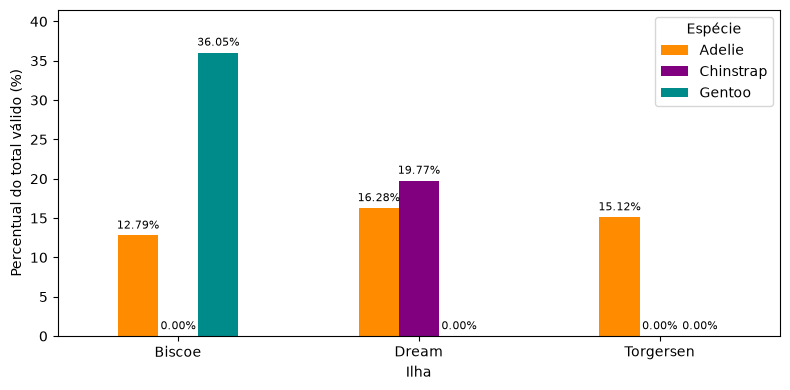

In [9]:
# Representar os percentuais do total
ax = pct.plot.bar(color=cores, figsize=(8, 4), rot=0)
ax.set(xlabel='Ilha', ylabel='Percentual do total válido (%)')
ax.legend(title='Espécie')

# Mostrar o percentual acima de cada barra
for barras in ax.containers:
    ax.bar_label(barras, fmt='%.2f%%', padding=3, fontsize=8)
ax.margins(y=0.15)

plt.tight_layout()
plt.show()

**Figura 2 — Percentuais conjuntos de ilha e espécie.** Gentoo em Biscoe corresponde a 36,05% dos 344 registros. A mudança para percentual preserva as proporções entre as barras da Figura 1, pois todas usam o mesmo denominador. A soma de todas as barras é 100%. Fonte: CARUBBI, 2026, com dados de HORST; HILL; GORMAN, 2020.

## 5. Percentuais condicionais e associação

Para comparar grupos de tamanhos diferentes, precisamos definir qual grupo representa 100%.

### 5.1 Percentuais por linha e por coluna

Um **percentual condicional** restringe o denominador ao grupo indicado na pergunta (PINHEIRO et al., 2009, pp. 60–65).

| Pergunta | Denominador | Cálculo |
| --- | --- | --- |
| Entre os registros desta ilha, quantos são desta espécie? | Total da linha | $100n_{ij}/n_{i\cdot}$ |
| Entre os registros desta espécie, quantos são desta ilha? | Total da coluna | $100n_{ij}/n_{\cdot j}$ |

O denominador deve ser positivo. Inverter o grupo de referência muda a pergunta.

In [10]:
# Comparar os dois denominadores
print('Gentoo entre os registros de Biscoe (%):', round(100 * 124 / 168, 2))
print('Biscoe entre os registros de Gentoo (%):', round(100 * 124 / 124, 2))

Gentoo entre os registros de Biscoe (%): 73.81
Biscoe entre os registros de Gentoo (%): 100.0


Gentoo representa 73,81% dos registros de Biscoe. Já Biscoe reúne 100% dos registros de Gentoo. O numerador é o mesmo, mas os denominadores são diferentes.

In [11]:
# Calcular percentuais dentro de cada ilha
por_ilha = 100 * pd.crosstab(df['ISLAND'], df['SPECIES'], normalize='index')
por_ilha = por_ilha.loc[ilhas, especies]
por_ilha.round(2)

SPECIES,Adelie,Chinstrap,Gentoo
ISLAND,,,
Biscoe,26.19,0.00,73.81
Dream,45.16,54.84,0.00
Torgersen,100.00,0.00,0.00


In [12]:
# Calcular percentuais dentro de cada espécie
por_especie = 100 * pd.crosstab(df['ISLAND'], df['SPECIES'], normalize='columns')
por_especie = por_especie.loc[ilhas, especies]
por_especie.round(2)

SPECIES,Adelie,Chinstrap,Gentoo
ISLAND,,,
Biscoe,28.95,0.0,100.0
Dream,36.84,100.0,0.0
Torgersen,34.21,0.0,0.0


In [13]:
# Conferir os totais condicionais
print('Soma por ilha:')
print(por_ilha.sum(axis=1))
print('Soma por espécie:')
print(por_especie.sum(axis=0))

Soma por ilha:
ISLAND
Biscoe       100.0
Dream        100.0
Torgersen    100.0
dtype: float64
Soma por espécie:
SPECIES
Adelie       100.0
Chinstrap    100.0
Gentoo       100.0
dtype: float64


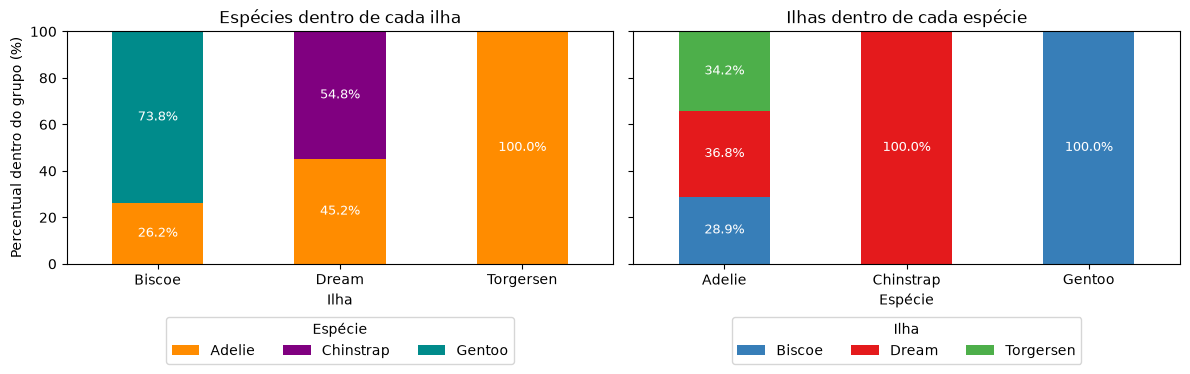

In [14]:
# Comparar os dois condicionamentos
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
por_ilha.plot.bar(stacked=True, color=cores, ax=ax[0], rot=0)
por_especie.T.plot.bar(stacked=True, color=cores_ilhas, ax=ax[1], rot=0)
ax[0].set(title='Espécies dentro de cada ilha', xlabel='Ilha', ylabel='Percentual dentro do grupo (%)', ylim=(0, 100))
ax[1].set(title='Ilhas dentro de cada espécie', xlabel='Espécie')
ax[0].legend(title='Espécie', bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=3)
ax[1].legend(title='Ilha', bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=3)

# Mostrar os percentuais dentro dos segmentos preenchidos
for eixo in ax:
    for barras in eixo.containers:
        rotulos = []
        for valor in barras.datavalues:
            rotulos.append(f'{valor:.1f}%' if valor > 0 else '')
        eixo.bar_label(barras, labels=rotulos, label_type='center', color='white', fontsize=9)

plt.tight_layout()
plt.show()

**Figura 3 — Distribuições condicionais por ilha e por espécie.** À esquerda, cada ilha representa 100% e sua composição em espécies varia. À direita, cada espécie representa 100%: Gentoo e Chinstrap concentram-se em uma ilha cada, enquanto Adelie se distribui pelas três. Os painéis respondem a perguntas diferentes. Fonte: CARUBBI, 2026, com dados de HORST; HILL; GORMAN, 2020.

### 5.2 Associação entre variáveis qualitativas

Um **perfil percentual** é a distribuição dos percentuais de uma variável dentro de um grupo. Há **associação descritiva** quando esses perfis mudam entre os grupos (MORETTIN; BUSSAB, 2010, pp. 90–92).

Se os perfis condicionais forem iguais à distribuição marginal, não há associação na tabela observada. Perfis apenas próximos não comprovam independência na população.

Em grupos pequenos, poucas observações podem provocar grandes mudanças percentuais. Leia os percentuais junto às contagens (PINHEIRO et al., 2009, pp. 62–63).

Retome a Figura 3: a composição das espécies é a mesma nas três ilhas? Compare com a distribuição marginal abaixo.

In [15]:
# Calcular a distribuição marginal das espécies
marginal = 100 * cont.sum() / cont.sum().sum()
marginal.round(2)

SPECIES
Adelie       44.19
Chinstrap    19.77
Gentoo       36.05
dtype: float64

No conjunto, Adelie representa 44,19%, Chinstrap 19,77% e Gentoo 36,05%. Esses percentuais diferem dos perfis por ilha. Portanto, há associação descritiva entre ilha e espécie nesta base. Isso não demonstra que a ilha cause as diferenças nem autoriza generalização automática.

## 6. Comparação entre grupos

Quando uma variável é qualitativa e a outra quantitativa, podemos resumir a medida dentro de cada categoria. Aqui, **espécie define os grupos** e **massa corporal é a medida comparada** (MORETTIN; BUSSAB, 2010, pp. 103–104).

Compare quantidade válida, média, mediana, desvio-padrão e quartis. Cada resumo usa apenas as massas preenchidas de seu grupo.

In [16]:
# Organizar a massa por espécie
grupo = df.groupby('SPECIES')['BODY_MASS']
grupo.count()

SPECIES
Adelie       151
Chinstrap     68
Gentoo       123
Name: BODY_MASS, dtype: int64

In [17]:
# Comparar médias de massa corporal em gramas
grupo.mean().round(2)

SPECIES
Adelie       3700.66
Chinstrap    3733.09
Gentoo       5076.02
Name: BODY_MASS, dtype: float64

In [18]:
# Comparar medianas de massa corporal em gramas
grupo.median()

SPECIES
Adelie       3700.0
Chinstrap    3700.0
Gentoo       5000.0
Name: BODY_MASS, dtype: float64

In [19]:
# Comparar desvios-padrão amostrais em gramas
grupo.std().round(2)

SPECIES
Adelie       458.57
Chinstrap    384.34
Gentoo       504.12
Name: BODY_MASS, dtype: float64

In [20]:
# Comparar quartis com interpolação linear
grupo.quantile([0.25, 0.5, 0.75], interpolation='linear')

SPECIES        
Adelie     0.25    3350.0
           0.50    3700.0
           0.75    4000.0
Chinstrap  0.25    3487.5
           0.50    3700.0
           0.75    3950.0
Gentoo     0.25    4700.0
           0.50    5000.0
           0.75    5500.0
Name: BODY_MASS, dtype: float64

Os tamanhos válidos são 151 Adelie, 68 Chinstrap e 123 Gentoo. Compare os resumos numéricos com os boxplots. A caixa representa os quartis e a mediana. Média e desvio-padrão são lidos nos resultados acima.

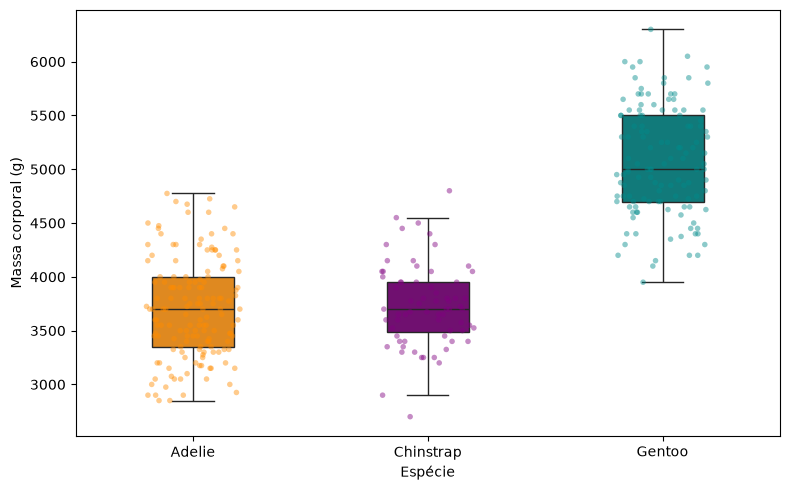

In [21]:
# Sobrepor observações aos boxplots
np.random.seed(0)
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='SPECIES', y='BODY_MASS', order=especies,
            hue='SPECIES', hue_order=especies, palette=cores,
            width=0.35, fliersize=0, legend=False, ax=ax)
sns.stripplot(data=df, x='SPECIES', y='BODY_MASS', order=especies,
              hue='SPECIES', hue_order=especies, palette=cores,
              jitter=0.2, alpha=0.45, size=4, legend=False, ax=ax)
ax.set(xlabel='Espécie', ylabel='Massa corporal (g)')
plt.tight_layout()
plt.show()

**Figura 4 — Massa corporal por espécie, com boxplots e observações individuais.** Gentoo apresenta mediana superior às de Adelie e Chinstrap, que exibem maior sobreposição. Os pontos mostram os valores observados, inclusive os discrepantes. Seu pequeno deslocamento horizontal serve apenas para evitar sobreposição visual. Fonte: CARUBBI, 2026, com dados de HORST; HILL; GORMAN, 2020.

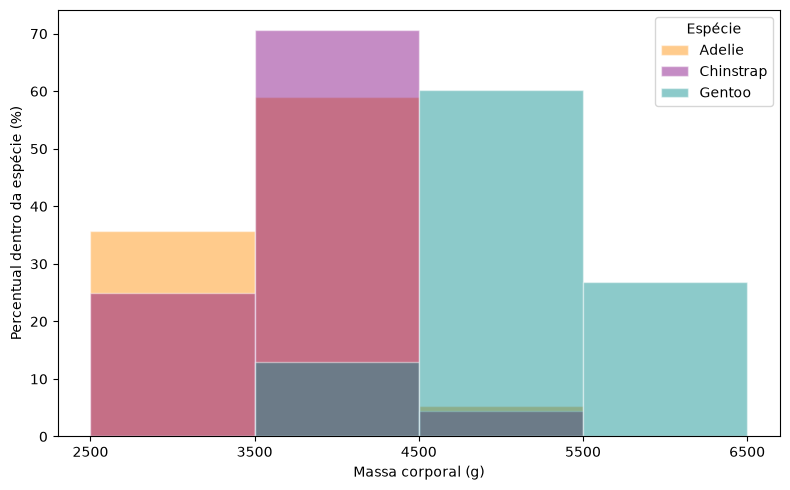

In [22]:
# Definir classes comuns em gramas
limites = [2500, 3500, 4500, 5500, 6500]

# Comparar histogramas percentuais por espécie
fig, ax = plt.subplots(figsize=(8, 5))
for i in range(len(especies)):
    massa = df.loc[df['SPECIES'] == especies[i], 'BODY_MASS'].dropna()
    pesos = np.full(len(massa), 100 / len(massa))
    ax.hist(massa, bins=limites, weights=pesos, color=cores[i],
            alpha=0.45, edgecolor='white', label=especies[i])
ax.set(xlabel='Massa corporal (g)', ylabel='Percentual dentro da espécie (%)')
ax.set_xticks(limites)
ax.legend(title='Espécie')
plt.tight_layout()
plt.show()

**Figura 5 — Histogramas percentuais de massa por espécie.** Adelie e Chinstrap concentram-se nas classes de menor massa, com sobreposição. Gentoo apresenta maior concentração nas classes superiores. As classes são comuns e as barras de cada espécie somam 100%, permitindo comparar grupos de tamanhos diferentes. A leitura depende dos limites escolhidos. Fonte: CARUBBI, 2026, com dados de HORST; HILL; GORMAN, 2020.

O **gráfico quantil–quantil (Q–Q)** compara valores que ocupam o mesmo percentual acumulado em dois grupos (MORETTIN; BUSSAB, 2010, pp. 107–108).

Nesta demonstração pronta:

- eixo horizontal: quantis de massa de Adelie.
- eixo vertical: quantis de massa de Chinstrap.
- diagonal $y=x$: referência de igualdade entre os quantis.

Um ponto acima da diagonal indica maior massa em Chinstrap naquele quantil. Abaixo, indica maior massa em Adelie. Cada ponto é um par de quantis, não um par de indivíduos.

Os grupos têm tamanhos diferentes. Por isso, calculamos os quantis nos mesmos percentuais, com interpolação linear. Não estamos comparando os dados com uma distribuição normal.

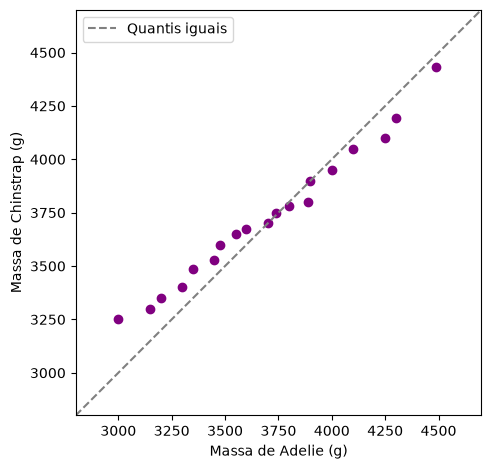

In [23]:
# Calcular quantis nos mesmos percentuais
p = np.linspace(0.05, 0.95, 19)
adelie = df.loc[df['SPECIES'] == 'Adelie', 'BODY_MASS'].dropna()
chinstrap = df.loc[df['SPECIES'] == 'Chinstrap', 'BODY_MASS'].dropna()
qa = adelie.quantile(p, interpolation='linear')
qc = chinstrap.quantile(p, interpolation='linear')

# Comparar os quantis com a diagonal de igualdade
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(qa, qc, color='purple')
ax.plot([2800, 4700], [2800, 4700], '--', color='gray', label='Quantis iguais')
ax.set(xlabel='Massa de Adelie (g)', ylabel='Massa de Chinstrap (g)',
       xlim=(2800, 4700), ylim=(2800, 4700))
ax.set_aspect('equal')
ax.legend()
plt.tight_layout()
plt.show()

**Figura 6 — Q–Q da massa corporal de Adelie e Chinstrap.** Entre os quantis de 5% e 95%, Chinstrap apresenta quantis inferiores maiores e quantis superiores geralmente menores que Adelie, com medianas iguais. Isso indica menor amplitude entre esses quantis em Chinstrap. A proximidade de parte dos pontos não comprova igualdade das distribuições. Os extremos abaixo de 5% e acima de 95% não estão representados. Fonte: CARUBBI, 2026, com dados de HORST; HILL; GORMAN, 2020.

Podemos também agrupar a massa em **faixas ordenadas**, criando uma variável qualitativa ordinal e cruzando-a com espécie (MORETTIN; BUSSAB, 2010, pp. 85–86).

Usaremos as mesmas classes do histograma: $[2500,3500)$, $[3500,4500)$, $[4500,5500)$ e $[5500,6500)$, em gramas. O colchete inclui o limite e o parêntese o exclui. Por exemplo, 3500 g pertence à segunda classe.

Os limites cobrem as massas observadas, de 2700 a 6300 g. A coluna original será preservada. As faixas não representam classificações biológicas como “leve” ou “pesado”.

In [24]:
# Criar faixas ordenadas sem alterar a massa original
rotulos = ['[2500, 3500)', '[3500, 4500)', '[4500, 5500)', '[5500, 6500)']
df['FAIXA_MASSA'] = pd.cut(df['BODY_MASS'], bins=limites,
                          labels=rotulos, right=False, ordered=True)
df[['BODY_MASS', 'FAIXA_MASSA']].head()

,BODY_MASS,FAIXA_MASSA
0,3750.0,"[3500, 4500)"
1,3800.0,"[3500, 4500)"
2,3250.0,"[2500, 3500)"
3,NaN,NaN
4,3450.0,"[2500, 3500)"


In [25]:
# Conferir cobertura e preservação das ausências
print('Massas fora das faixas:', (df['BODY_MASS'].notna() & df['FAIXA_MASSA'].isna()).sum())
print('Massas ausentes:', df['BODY_MASS'].isna().sum())
print('Faixas ausentes:', df['FAIXA_MASSA'].isna().sum())

Massas fora das faixas: 0
Massas ausentes: 2
Faixas ausentes: 2


In [26]:
# Cruzar espécie e faixa de massa
faixas = pd.crosstab(df['SPECIES'], df['FAIXA_MASSA'])
faixas

FAIXA_MASSA,"[2500, 3500)","[3500, 4500)","[4500, 5500)","[5500, 6500)"
SPECIES,,,,
Adelie,54,89,8,0
Chinstrap,17,48,3,0
Gentoo,0,16,74,33


In [27]:
# Calcular percentuais de faixas dentro de cada espécie
pct_faixas = 100 * pd.crosstab(df['SPECIES'], df['FAIXA_MASSA'], normalize='index')
pct_faixas.round(2)

FAIXA_MASSA,"[2500, 3500)","[3500, 4500)","[4500, 5500)","[5500, 6500)"
SPECIES,,,,
Adelie,35.76,58.94,5.30,0.00
Chinstrap,25.00,70.59,4.41,0.00
Gentoo,0.00,13.01,60.16,26.83


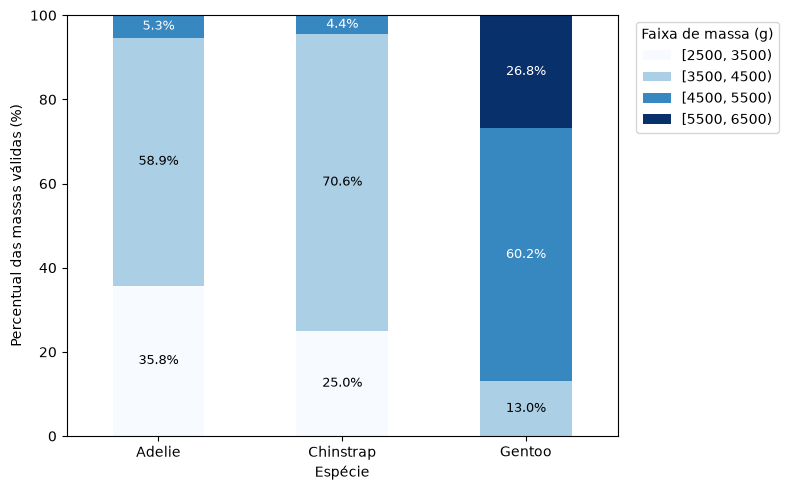

In [28]:
# Comparar a composição das faixas por espécie
ax = pct_faixas.loc[especies].plot.bar(stacked=True, cmap='Blues', figsize=(8, 5), rot=0)
ax.set(xlabel='Espécie', ylabel='Percentual das massas válidas (%)', ylim=(0, 100))
ax.legend(title='Faixa de massa (g)', bbox_to_anchor=(1.02, 1), loc='upper left')

# Mostrar os percentuais com contraste em cada faixa
for i, barras in enumerate(ax.containers):
    rotulos = []
    for valor in barras.datavalues:
        rotulos.append(f'{valor:.1f}%' if valor > 0 else '')
    cor = 'black' if i < 2 else 'white'
    ax.bar_label(barras, labels=rotulos, label_type='center', color=cor, fontsize=9)

plt.tight_layout()
plt.show()

**Figura 7 — Faixas de massa dentro de cada espécie.** Cada barra representa 100% das massas válidas da espécie. Gentoo concentra maior participação nas faixas superiores, enquanto Adelie e Chinstrap têm composição mais próxima. Os segmentos representam os mesmos percentuais do histograma, organizados como composição de cada grupo. Fonte: CARUBBI, 2026, com dados de HORST; HILL; GORMAN, 2020.

O agrupamento perde as diferenças entre valores de uma mesma classe. Alterar os limites pode mudar a comparação. Por isso, as faixas complementam os resumos da massa original.

**Interpretação:** como espécie e ilha estão associadas nesta base, a composição das espécies precisa ser considerada antes de atribuir diferenças de massa à ilha. Os resultados são descritivos e não demonstram causalidade.

## 7. Estudo e exercícios

### 7.1 Materiais didáticos

- PINHEIRO et al. (2009), seção 2.1, pp. 60–65: tabelas e percentuais condicionais.
- MORETTIN; BUSSAB (2010), seção 4.1, pp. 85–86: escolha dos procedimentos e agrupamento em classes.
- MORETTIN; BUSSAB (2010), seções 4.2–4.3, pp. 87–92: frequências conjuntas, marginais e associação.
- MORETTIN; BUSSAB (2010), seção 4.6, pp. 103–104, até a Figura 4.9: medidas e gráficos por grupo.
- MORETTIN; BUSSAB (2010), seção 4.7, pp. 107–108: gráfico quantil–quantil entre grupos.

### 7.2 Exercícios indicados

PINHEIRO et al. (2009), exercício **2.2_P, itens a e b**, p. 82. Identifique o grupo usado como denominador antes de calcular cada percentual.

## 8. Referências

1. MORETTIN, Pedro A.; BUSSAB, Wilton O. *Estatística básica*. 6. ed. São Paulo: Saraiva, 2010.
2. PINHEIRO, João Ismael D. et al. *Estatística básica: a arte de trabalhar com dados*. Rio de Janeiro: Elsevier, 2009.
3. HORST, Allison Marie; HILL, Alison Presmanes; GORMAN, Kristen B. *palmerpenguins: Palmer Archipelago (Antarctica) penguin data*. Zenodo, 2020. DOI: [10.5281/zenodo.3960218](https://doi.org/10.5281/zenodo.3960218).